In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score

# (a) Custom K-Means Implementation

In [2]:
class SimpleKMeans:
    def __init__(self, k=3, max_iters=100, random_state=42):
        self.k = k
        self.max_iters = max_iters
        np.random.seed(random_state)
        self.centroids = None
        self.inertia = 0

    def fit_predict(self, X):
        # Randomly initialize centroids from the existing data points
        random_indices = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.max_iters):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # Update centroids to be the mean of points in each cluster
            new_centroids = np.array([X[labels == i].mean(axis=0) if np.sum(labels == i) > 0
                                      else self.centroids[i] for i in range(self.k)])

            # Check for convergence
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

        # Calculate Inertia
        self.inertia = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            self.inertia += np.sum((cluster_points - self.centroids[i]) ** 2)

        return labels

# (b) Custom StandardScaler Implementation

In [3]:
def custom_standard_scaler(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    return (X - mu) / sigma

# Execution & Evaluation

In [4]:
# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Running Custom K-Means")

# Unscaled Data
kmeans_unscaled = SimpleKMeans(k=3)
labels_unscaled = kmeans_unscaled.fit_predict(X)
inertia_unscaled = kmeans_unscaled.inertia
ari_unscaled = adjusted_rand_score(y, labels_unscaled)

print("\n1. Unscaled Features:")
print(f"   Inertia: {inertia_unscaled:.4f}")
print(f"   Adjusted Rand Index (ARI): {ari_unscaled:.4f}")

# Scaled Data
X_scaled = custom_standard_scaler(X)
kmeans_scaled = SimpleKMeans(k=3)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
inertia_scaled = kmeans_scaled.inertia
ari_scaled = adjusted_rand_score(y, labels_scaled)

print("\n2. Scaled Features:")
print(f"   Inertia: {inertia_scaled:.4f}")
print(f"   Adjusted Rand Index (ARI): {ari_scaled:.4f}")

Running Custom K-Means

1. Unscaled Features:
   Inertia: 78.8514
   Adjusted Rand Index (ARI): 0.7302

2. Scaled Features:
   Inertia: 140.0328
   Adjusted Rand Index (ARI): 0.5923


# Visualizing the Clusters

Unscaled Data Clusters:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

Scaled Data Clusters:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 0 2 2
 0 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


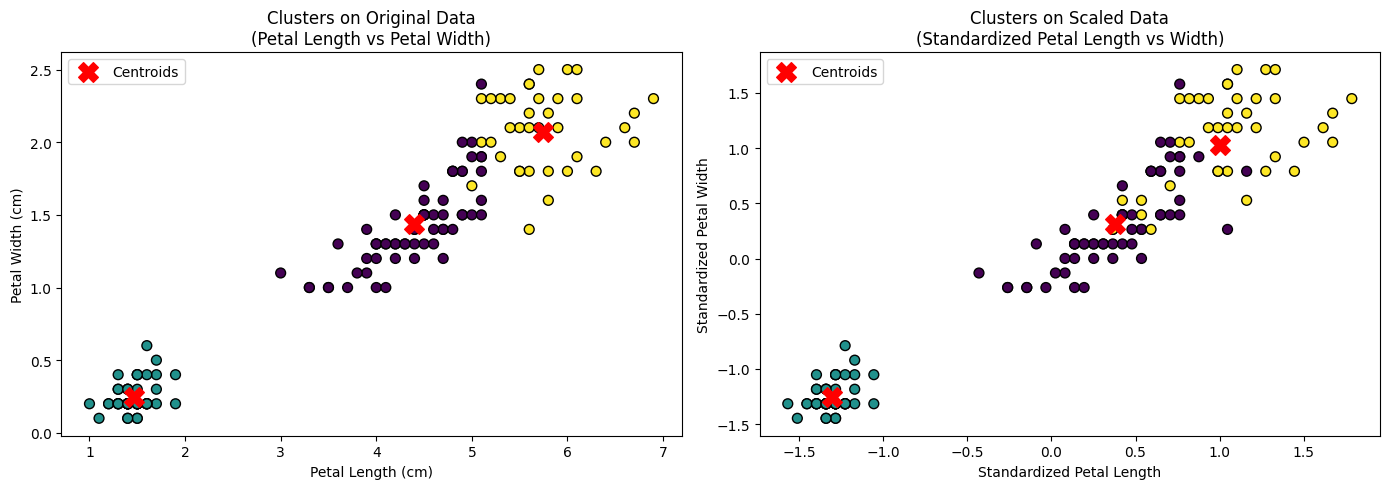

In [7]:
# import matplotlib.pyplot as plt

# print("Unscaled Data Clusters:")
# print(labels_unscaled)

# print("\nScaled Data Clusters:")
# print(labels_scaled)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Plot 1: Unscaled Clusters
# axes[0].scatter(X[:, 2], X[:, 3], c=labels_unscaled, cmap='viridis', edgecolor='k', s=50)
# axes[0].scatter(kmeans_unscaled.centroids[:, 2], kmeans_unscaled.centroids[:, 3], c='red', marker='X', s=200, label='Centroids')
# axes[0].set_title("Clusters on Original Data\n(Petal Length vs Petal Width)")
# axes[0].set_xlabel("Petal Length (cm)")
# axes[0].set_ylabel("Petal Width (cm)")
# axes[0].legend()

# # Plot 2: Scaled Clusters
# axes[1].scatter(X_scaled[:, 2], X_scaled[:, 3], c=labels_scaled, cmap='viridis', edgecolor='k', s=50)
# axes[1].scatter(kmeans_scaled.centroids[:, 2], kmeans_scaled.centroids[:, 3], c='red', marker='X', s=200, label='Centroids')
# axes[1].set_title("Clusters on Scaled Data\n(Standardized Petal Length vs Width)")
# axes[1].set_xlabel("Standardized Petal Length")
# axes[1].set_ylabel("Standardized Petal Width")
# axes[1].legend()

# plt.tight_layout()
# plt.show()